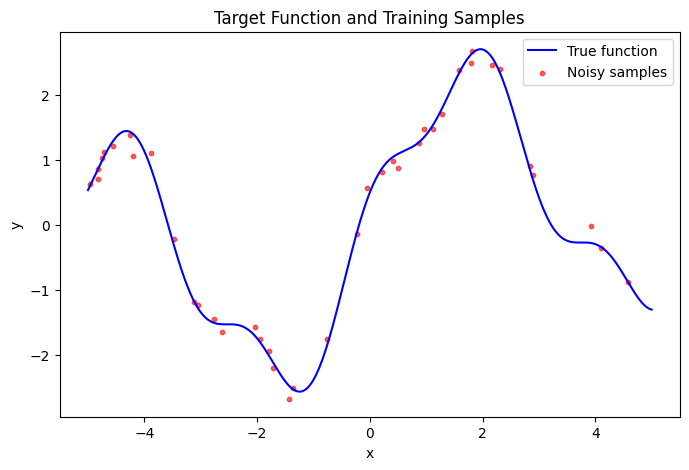

Epoch 0, Loss: 5.868392
Epoch 5000, Loss: 1.300094
Epoch 10000, Loss: 0.700879
Epoch 15000, Loss: 0.445385
Epoch 20000, Loss: 0.312983
Epoch 25000, Loss: 0.239867


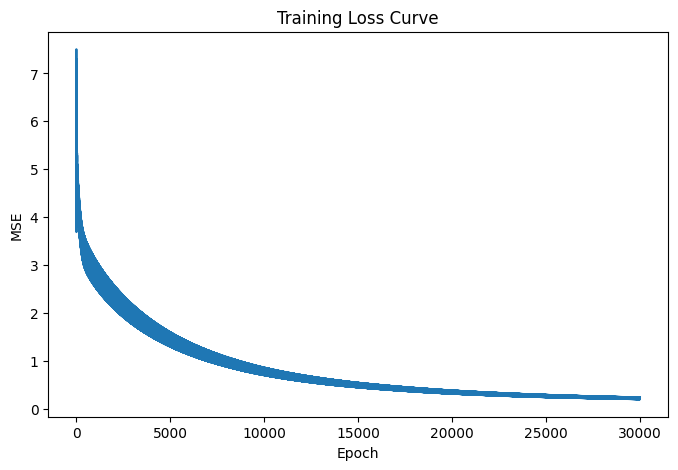

Test MSE: 0.217928


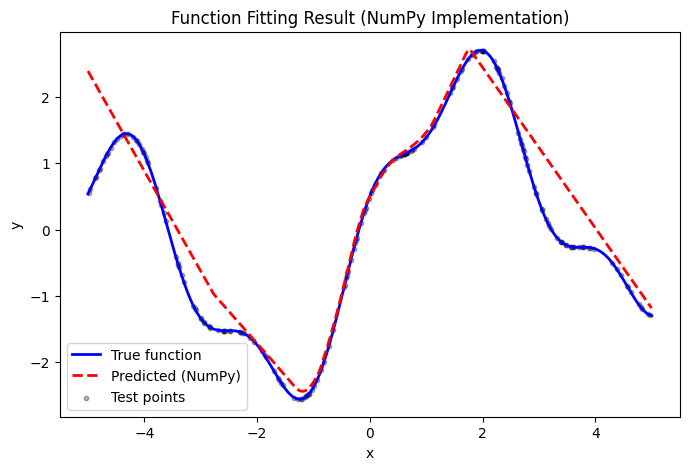

In [ ]:
#函数拟合：使用 NumPy 实现两层 ReLU 网络

# %% [code]
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

#1. 定义目标函数与生成数据
def target_func(x):
    """目标函数：2*sin(x) + 0.5*cos(3x) + 0.2*x"""
    return 2 * np.sin(x) + 0.5 * np.cos(3 * x) + 0.2 * x

# 生成数据
x_data = np.linspace(-5, 5, 1000).reshape(-1, 1)
y_data = target_func(x_data)

# 划分训练集和测试集 (80% 训练, 20% 测试)
indices = np.random.permutation(len(x_data))
train_idx, test_idx = indices[:800], indices[800:]
x_train, y_train = x_data[train_idx], y_data[train_idx]
x_test, y_test = x_data[test_idx], y_data[test_idx]

# 添加噪声（可选）
noise_std = 0.1
y_train_noisy = y_train + noise_std * np.random.randn(*y_train.shape)

# 绘制目标函数和采样点
plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'b-', label='True function')
plt.scatter(x_train[::20], y_train_noisy[::20], s=10, c='r', alpha=0.6, label='Noisy samples')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Target Function and Training Samples')
plt.savefig('target_function_numpy.png', dpi=300, bbox_inches='tight')
plt.show()

#2. 定义两层 ReLU 网络类
class ReLUNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # He 初始化
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))

        # 动量缓存
        self.vW1, self.vb1 = np.zeros_like(self.W1), np.zeros_like(self.b1)
        self.vW2, self.vb2 = np.zeros_like(self.W2), np.zeros_like(self.b2)

    def forward(self, x):
        self.x = x
        self.z1 = np.dot(x, self.W1) + self.b1
        self.a1 = np.maximum(0, self.z1)          # ReLU 激活
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2

    def backward(self, y_pred, y_true, lr, momentum=0.9):
        m = y_true.shape[0]

        # 输出层梯度 (MSE loss: L = 1/m * sum((y_pred - y_true)^2) -> dL/dz2 = 2*(y_pred - y_true)/m)
        dz2 = 2 * (y_pred - y_true) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # 隐藏层梯度
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1.copy()
        dz1[self.z1 <= 0] = 0                     # ReLU 导数
        dW1 = np.dot(self.x.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 梯度裁剪
        for grad in [dW1, db1, dW2, db2]:
            np.clip(grad, -1.0, 1.0, out=grad)

        # 动量更新
        self.vW1 = momentum * self.vW1 - lr * dW1
        self.vb1 = momentum * self.vb1 - lr * db1
        self.vW2 = momentum * self.vW2 - lr * dW2
        self.vb2 = momentum * self.vb2 - lr * db2

        self.W1 += self.vW1
        self.b1 += self.vb1
        self.W2 += self.vW2
        self.b2 += self.vb2

#3. 训练模型
model = ReLUNetwork(input_size=1, hidden_size=1024, output_size=1)

epochs = 30000
lr = 0.002
losses = []

for epoch in range(epochs):
    y_pred = model.forward(x_train)
    loss = np.mean((y_pred - y_train_noisy)**2)
    losses.append(loss)
    model.backward(y_pred, y_train_noisy, lr)

    if epoch % 5000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

# 绘制训练损失曲线
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training Loss Curve')
plt.savefig('training_loss_numpy.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 测试模型并可视化
y_test_pred = model.forward(x_test)
test_mse = np.mean((y_test_pred - y_test)**2)
print(f"Test MSE: {test_mse:.6f}")

# 在整个区间上预测用于绘图
x_plot = np.linspace(-5, 5, 500).reshape(-1, 1)
y_plot_pred = model.forward(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'b-', linewidth=2, label='True function')
plt.plot(x_plot, y_plot_pred, 'r--', linewidth=2, label='Predicted (NumPy)')
plt.scatter(x_test, y_test, s=10, c='k', alpha=0.3, label='Test points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Function Fitting Result (NumPy Implementation)')
plt.savefig('fitting_result_numpy.png', dpi=300, bbox_inches='tight')
plt.show()